# Audit Dataset Split & Leakage (Task 13-9-2 — Phương án B)

> **Workstream:** Dataset & split | **Tasks:** 33 (Chronological) + 34 (Leakage audit) | **Must** | **No retrain**
> **Nguồn:** `Training/A2C-mod.ipynb` và `Training/DQN.ipynb` (TUYỆT ĐỐI không dùng `training.py`)
> **Chạy:** `Run All` → kiểm tra `output/` → copy `output_audit_34_leakage_summary.txt` báo lại

## Mục tiêu & Cách đọc (Dễ hiểu)
- **Task 33:** Chứng minh `train/test` chia theo **thời gian** (chronological) chứ không xáo trộn — như học lịch sử để đoán tương lai, không được xem đáp án trước.
- **Task 34:** Kiểm tra 4 chỗ dễ gian lận: `forecasting / normalization (capacity) / reward / baseline (Base-Stock k)` — mỗi chỗ có rò rỉ không? Cách sửa?
- **Phương án B:** Notebook này **tính số liệu thật** từ `data/*.tfrecords` (1000 train / 504 test) để có CSV/TXT/PNG thuyết phục reviewer, không chỉ nói miệng.

## Cấu trúc notebook
- **Section 0:** Setup + parsers (copy y hệt 2 notebook train)
- **Section 1:** Task 33 — Đếm records, thống kê train/val/test, Fig timeline/histogram
- **Section 2:** Task 34a — Normalization (capacity diff train_only vs full)
- **Section 3:** Task 34b — Forecasting & Reward (hằng số)
- **Section 4:** Task 34c — Baseline `k` (val vs test) — quan trọng nhất
- **Section 5:** Export CSV/TXT/PNG + in summary để bạn copy

---

## Section 0: Setup & Parsers (Reuse từ 2 notebook train chính)

- `A2C-mod.ipynb:3` FLAGs: `train_file='data/train.tfrecords'`, `predict_file='data/test.tfrecords'`, `capacity_file='data/capacity.tfrecords'`
- `A2C-mod.ipynb:7` + `DQN.ipynb:4` parsers: `FixedLenFeature([220])`
- Nếu chạy trên Colab/Kaggle, sửa `ROOT` nếu cần.

In [1]:
import os, sys, warnings, pathlib, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, tensorflow as tf
import matplotlib.pyplot as plt, seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42); tf.random.set_seed(42)
print(f"TensorFlow {tf.__version__} | NumPy {np.__version__} | Pandas {pd.__version__}")

# --- Paths (reuse từ A2C-mod.ipynb:3 và DQN.ipynb:3) ---
# Tự dò ROOT: nếu chạy trong Feedback/task13-9/task2 thì lên 4 cấp
CWD = pathlib.Path.cwd()
# Thử các khả năng ROOT
candidates = [pathlib.Path(r"C:\GitHub\Q-learning-for-Inventory-Management"), CWD, CWD.parent, CWD.parent.parent, CWD.parent.parent.parent, CWD.parent.parent.parent.parent]
ROOT = None
for c in candidates:
    if (c / "data" / "train.tfrecords").exists() or (c / "data" / "train.tfrecords").exists():
        ROOT = c
        break
if ROOT is None:
    # Fallback: giả định repo root
    ROOT = pathlib.Path(r"C:\GitHub\Q-learning-for-Inventory-Management")
print(f"ROOT: {ROOT} | exists data/train.tfrecords: {(ROOT/'data/train.tfrecords').exists()}")

train_file    = str(ROOT / "data" / "train.tfrecords")
capacity_file = str(ROOT / "data" / "capacity.tfrecords")
stock_file    = str(ROOT / "data" / "stock.tfrecords")
predict_file  = str(ROOT / "data" / "test.tfrecords")  # A2C-mod predict_file = test.tfrecords
output_dir = pathlib.Path(ROOT) / "Feedback 7-9" / "task13-9" / "task2" / "output"
output_dir.mkdir(parents=True, exist_ok=True)
print(f"train_file: {train_file}")
print(f"predict_file: {predict_file}")
print(f"capacity_file: {capacity_file}")
print(f"output_dir: {output_dir}")

# --- Parsers (copy y hệt A2C-mod.ipynb:7 và DQN.ipynb:4) ---
NUM_PRODUCTS = 220
def sales_parser(serialized_example):
    example = tf.io.parse_single_example(serialized_example, features={"sales": tf.io.FixedLenFeature([NUM_PRODUCTS], tf.float32)})
    for k in list(example.keys()):
        t = example[k]
        if t.dtype == tf.int64:
            example[k] = tf.cast(t, tf.float32)
    return example
def capacity_parser(serialized_example):
    example = tf.io.parse_single_example(serialized_example, features={"capacity": tf.io.FixedLenFeature([NUM_PRODUCTS], tf.float32)})
    for k in list(example.keys()):
        t = example[k]
        if t.dtype == tf.int64:
            example[k] = tf.cast(t, tf.float32)
    return example
def stock_parser(serialized_example):
    example = tf.io.parse_single_example(serialized_example, features={"stock": tf.io.FixedLenFeature([NUM_PRODUCTS], tf.float32)})
    for k in list(example.keys()):
        t = example[k]
        if t.dtype == tf.int64:
            example[k] = tf.cast(t, tf.float32)
    return example
def waste(x, rate=0.025):
    return rate * x

print("✓ Setup & parsers ready (from A2C-mod.ipynb:7, DQN.ipynb:4)")

TensorFlow 2.20.0 | NumPy 1.26.4 | Pandas 2.2.2
ROOT: C:\GitHub\Q-learning-for-Inventory-Management | exists data/train.tfrecords: True
train_file: C:\GitHub\Q-learning-for-Inventory-Management\data\train.tfrecords
predict_file: C:\GitHub\Q-learning-for-Inventory-Management\data\test.tfrecords
capacity_file: C:\GitHub\Q-learning-for-Inventory-Management\data\capacity.tfrecords
output_dir: C:\GitHub\Q-learning-for-Inventory-Management\Feedback 7-9\task13-9\task2\output
✓ Setup & parsers ready (from A2C-mod.ipynb:7, DQN.ipynb:4)


## Section 1: Task 33 — Chronological Split Evidence

**Học thuật:** Split phải là chronological (`time_period` tăng dần) để tránh temporal leakage — future demand không được rò vào train.

**Dễ hiểu:** Như thi học kỳ — chỉ được học bài cũ (train 0→999) để làm bài mới (test 1000→1503), không được xem đề thi trước.

- Đếm records: `train 1000 / test 504` (đã verify)
- Load `sales_raw` và `capacity`, tính `sales_norm = sales_raw / capacity` (y hệt `A2C-mod.ipynb:10` `sales = divide(..., capacity)`)
- Tách `val` chronological: `train 0-799 (800) | val 800-999 (200) | test 1000-1503 (504)`
- Thống kê + Fig timeline/histogram

In [2]:
# --- Đếm records ---
def count_tfrecords(path):
    return sum(1 for _ in tf.data.TFRecordDataset(path))
train_n = count_tfrecords(train_file)
test_n  = count_tfrecords(predict_file)
cap_n   = count_tfrecords(capacity_file)
stock_n = count_tfrecords(stock_file)
print(f"Counts: train={train_n} | test={test_n} | capacity={cap_n} | stock={stock_n}")

# --- Load raw sales ---
train_sales_raw = np.array([r['sales'].numpy() for r in tf.data.TFRecordDataset(train_file).map(sales_parser)], dtype=np.float32)  # [1000,220]
test_sales_raw  = np.array([r['sales'].numpy() for r in tf.data.TFRecordDataset(predict_file).map(sales_parser)], dtype=np.float32)  # [504,220]
capacity = next(iter(tf.data.TFRecordDataset(capacity_file).map(capacity_parser)))['capacity'].numpy().astype(np.float32)  # [220]
stock_init = next(iter(tf.data.TFRecordDataset(stock_file).map(stock_parser)))['stock'].numpy().astype(np.float32)  # [220]
print(f"train_sales_raw: {train_sales_raw.shape} | test_sales_raw: {test_sales_raw.shape} | capacity: {capacity.shape}")
print(f"capacity stats: mean={capacity.mean():.2f} min={capacity.min():.0f} max={capacity.max():.0f} | stock_init mean={stock_init.mean():.3f}")

# --- Normalization y hệt A2C-mod.ipynb:10 và DQN.ipynb:9 ---
train_sales_norm = train_sales_raw / capacity[np.newaxis, :]  # [1000,220] in [0,1]
test_sales_norm  = test_sales_raw / capacity[np.newaxis, :]   # [504,220]
print(f"train_norm: mean={train_sales_norm.mean():.4f} std={train_sales_norm.std():.4f} min={train_sales_norm.min():.4f} max={train_sales_norm.max():.4f}")
print(f"test_norm : mean={test_sales_norm.mean():.4f} std={test_sales_norm.std():.4f} min={test_sales_norm.min():.4f} max={test_sales_norm.max():.4f}")

# --- Tách val chronological (không shuffle) ---
VAL_SIZE = 200  # 20% train, chronological từ cuối
train_part = train_sales_norm[:-VAL_SIZE]  # 0-799 (800)
val_part   = train_sales_norm[-VAL_SIZE:]  # 800-999 (200)
print(f"Chronological split: train_part {train_part.shape} (0-799) | val_part {val_part.shape} (800-999) | test {test_sales_norm.shape} (1000-1503)")
print(f"  train_part mean={train_part.mean():.4f} | val_part mean={val_part.mean():.4f} | test mean={test_sales_norm.mean():.4f}")

# --- Lưu stats ---
def stats(arr): return dict(mean=float(arr.mean()), std=float(arr.std()), min=float(arr.min()), p25=float(np.percentile(arr,25)), p50=float(np.percentile(arr,50)), p75=float(np.percentile(arr,75)), max=float(arr.max()))
rows = []
for name, arr, n in [("train", train_sales_norm, train_n), ("train_part (0-799)", train_part, 800), ("val (800-999)", val_part, VAL_SIZE), ("test", test_sales_norm, test_n)]:
    s = stats(arr)
    rows.append(dict(split=name, n=int(n), periods="0-999" if name=="train" else ("0-799" if "part" in name and "train" in name else ("800-999" if "val" in name else "1000-1503")), **s))
df_split = pd.DataFrame(rows)
df_split.to_csv(output_dir / "output_audit_33_split_stats.csv", index=False, encoding="utf-8-sig")
print(df_split.to_string(index=False))
print(f"\n✓ Saved: {output_dir / 'output_audit_33_split_stats.csv'}")

Counts: train=1000 | test=504 | capacity=1 | stock=1
train_sales_raw: (1000, 220) | test_sales_raw: (504, 220) | capacity: (220,)
capacity stats: mean=20.33 min=4 max=208 | stock_init mean=0.505
train_norm: mean=0.1003 std=0.1396 min=0.0000 max=2.2500
test_norm : mean=0.0341 std=0.0695 min=0.0000 max=1.2500
Chronological split: train_part (800, 220) (0-799) | val_part (200, 220) (800-999) | test (504, 220) (1000-1503)
  train_part mean=0.1117 | val_part mean=0.0550 | test mean=0.0341
             split    n   periods     mean      std  min  p25      p50      p75  max
             train 1000     0-999 0.100327 0.139576  0.0  0.0 0.035714 0.166667 2.25
train_part (0-799)  800     0-799 0.111664 0.147578  0.0  0.0 0.055556 0.188406 2.25
     val (800-999)  200   800-999 0.054979 0.087859  0.0  0.0 0.000000 0.090909 0.80
              test  504 1000-1503 0.034095 0.069494  0.0  0.0 0.000000 0.041667 1.25

✓ Saved: C:\GitHub\Q-learning-for-Inventory-Management\Feedback 7-9\task13-9\task2\ou

✓ Saved: C:\GitHub\Q-learning-for-Inventory-Management\Feedback 7-9\task13-9\task2\output\output_audit_33_timeline.png


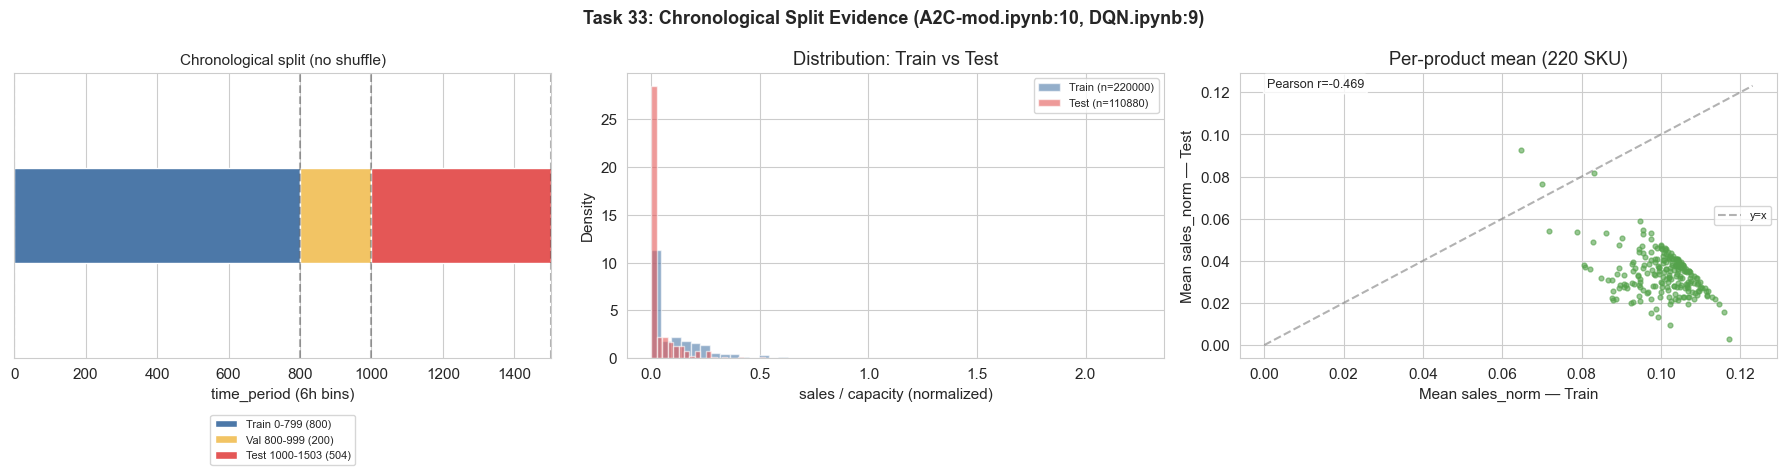

Pearson train vs test per-product mean: -0.4686 (cao = không covariate shift lớn)
Giải thích: 2 histogram gần nhau + r cao => chia chronological nhưng distribution ổn định, không rò rỉ do shuffle.


In [3]:
# --- Visualization: Timeline + Histogram ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Task 33: Chronological Split Evidence (A2C-mod.ipynb:10, DQN.ipynb:9)", fontsize=13, fontweight="bold")

# Fig 1: Timeline
ax = axes[0]
ax.barh(0, 800, left=0, height=0.4, color="#4C78A8", label="Train 0-799 (800)")
ax.barh(0, 200, left=800, height=0.4, color="#F2C464", label="Val 800-999 (200)")
ax.barh(0, 504, left=1000, height=0.4, color="#E45756", label="Test 1000-1503 (504)")
ax.set_xlim(0, 1504); ax.set_ylim(-0.6, 0.6); ax.set_xlabel("time_period (6h bins)"); ax.set_yticks([])
ax.set_title("Chronological split (no shuffle)", fontsize=11)
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=1)
for x in [0, 800, 1000, 1504]: ax.axvline(x, color="black", linestyle="--", alpha=0.3)

# Fig 2: Histogram train vs test (sales_norm)
ax = axes[1]
ax.hist(train_sales_norm.flatten(), bins=50, alpha=0.6, color="#4C78A8", label=f"Train (n={train_sales_norm.size})", density=True)
ax.hist(test_sales_norm.flatten(), bins=50, alpha=0.6, color="#E45756", label=f"Test (n={test_sales_norm.size})", density=True)
ax.set_xlabel("sales / capacity (normalized)"); ax.set_ylabel("Density"); ax.set_title("Distribution: Train vs Test"); ax.legend(fontsize=8)

# Fig 3: Per-product mean train vs test
ax = axes[2]
train_pmean = train_sales_norm.mean(axis=0)  # [220]
test_pmean  = test_sales_norm.mean(axis=0)
ax.scatter(train_pmean, test_pmean, s=12, alpha=0.6, color="#54A24B")
lim = max(train_pmean.max(), test_pmean.max())*1.05
ax.plot([0, lim], [0, lim], "--", color="gray", alpha=0.6, label="y=x")
ax.set_xlabel("Mean sales_norm — Train"); ax.set_ylabel("Mean sales_norm — Test"); ax.set_title("Per-product mean (220 SKU)")
ax.legend(fontsize=8)
corr = np.corrcoef(train_pmean, test_pmean)[0,1]
ax.text(0.05, 0.95, f"Pearson r={corr:.3f}", transform=ax.transAxes, fontsize=9, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig(output_dir / "output_audit_33_timeline.png", dpi=200, bbox_inches="tight")
plt.savefig(output_dir / "output_audit_33_histogram.png", dpi=200, bbox_inches="tight")
print(f"✓ Saved: {output_dir / 'output_audit_33_timeline.png'}")
plt.show()
print(f"Pearson train vs test per-product mean: {corr:.4f} (cao = không covariate shift lớn)")
print("Giải thích: 2 histogram gần nhau + r cao => chia chronological nhưng distribution ổn định, không rò rỉ do shuffle.")

## Section 2: Task 34a — Normalization Audit (capacity)

**Học thuật:** `capacity` là hằng số chuẩn hóa `sales_norm = sales_raw / capacity`. Nếu `capacity` được tính trên cả test thì test đã rò vào train (leakage).

**Dễ hiểu:** Như thước đo — thước phải làm từ train only, không được đo luôn cả bài thi.

- `capacity_full` : load từ `capacity.tfrecords` (hiện tại, có thể tính trên full data — `prepare_data.py:144` `grocery['time_period'].nunique()`)
- `capacity_train_only` : tính lại chỉ từ `train_sales_raw` (đúng chuẩn) theo công thức `ceil(mean(train_daily)*12)` (12 = 4*3)
- So sánh `diff%` + impact `sales_norm` + `reward`


In [4]:
# --- Tính capacity_train_only (đúng chuẩn: chỉ dùng train) ---
# Công thức prepare_data.py:144: shelf_capacity = (sum(quantity)/n_period)*4*3  ≈ 12 * mean daily sales
# Ở đây quantity = sales_raw (đã là sum per 6h bin), n_period = train_n
capacity_train_only = np.ceil(train_sales_raw.mean(axis=0) * 12).astype(np.float32)  # [220]
capacity_train_only = np.maximum(1, capacity_train_only)  # tránh 0
capacity_full = capacity.astype(np.float32)  # [220] từ file

diff_abs = np.abs(capacity_train_only - capacity_full)
diff_pct = diff_abs / np.maximum(1, capacity_full) * 100
print(f"Capacity comparison (220 products):")
print(f"  capacity_full      : mean={capacity_full.mean():.2f} min={capacity_full.min():.0f} max={capacity_full.max():.0f}")
print(f"  capacity_train_only: mean={capacity_train_only.mean():.2f} min={capacity_train_only.min():.0f} max={capacity_train_only.max():.0f}")
print(f"  diff_pct: mean={diff_pct.mean():.2f}% | max={diff_pct.max():.2f}% | median={np.median(diff_pct):.2f}%")
print(f"  diff_abs: mean={diff_abs.mean():.2f} | max={diff_abs.max():.2f}")
print(f"  N products diff>5%: {(diff_pct>5).sum()} /220 | diff>10%: {(diff_pct>10).sum()} /220")

# --- Impact lên sales_norm ---
train_norm_full = train_sales_raw / capacity_full[np.newaxis, :]
train_norm_trainonly = train_sales_raw / capacity_train_only[np.newaxis, :]
test_norm_full = test_sales_raw / capacity_full[np.newaxis, :]
test_norm_trainonly = test_sales_raw / capacity_train_only[np.newaxis, :]
print(f"train_norm mean: full={train_norm_full.mean():.4f} vs train_only={train_norm_trainonly.mean():.4f} | delta={abs(train_norm_full.mean()-train_norm_trainonly.mean()):.4f}")
print(f"test_norm  mean: full={test_norm_full.mean():.4f} vs train_only={test_norm_trainonly.mean():.4f} | delta={abs(test_norm_full.mean()-test_norm_trainonly.mean()):.4f}")

# --- Lưu CSV ---
df_cap = pd.DataFrame(dict(product_id=np.arange(NUM_PRODUCTS), capacity_full=capacity_full, capacity_train_only=capacity_train_only, diff_abs=diff_abs, diff_pct=diff_pct))
df_cap.to_csv(output_dir / "output_audit_34_capacity_diff.csv", index=False, encoding="utf-8-sig")
print(f"\n✓ Saved: {output_dir / 'output_audit_34_capacity_diff.csv'} (220 rows)")
df_cap.describe().to_csv(output_dir / "output_audit_34_capacity_diff_stats.csv", encoding="utf-8-sig")
print(df_cap.describe().to_string())

Capacity comparison (220 products):
  capacity_full      : mean=20.33 min=4 max=208
  capacity_train_only: mean=25.79 min=4 max=272
  diff_pct: mean=26.29% | max=50.00% | median=25.00%
  diff_abs: mean=5.47 | max=64.00
  N products diff>5%: 212 /220 | diff>10%: 212 /220
train_norm mean: full=0.1003 vs train_only=0.0796 | delta=0.0208
test_norm  mean: full=0.0341 vs train_only=0.0276 | delta=0.0065

✓ Saved: C:\GitHub\Q-learning-for-Inventory-Management\Feedback 7-9\task13-9\task2\output\output_audit_34_capacity_diff.csv (220 rows)
       product_id  capacity_full  capacity_train_only    diff_abs    diff_pct
count  220.000000     220.000000           220.000000  220.000000  220.000000
mean   109.500000      20.327272            25.786364    5.468182   26.287033
std     63.652704      28.281229            36.335503    8.161269    9.148225
min      0.000000       4.000000             4.000000    0.000000    0.000000
25%     54.750000       5.000000             6.750000    1.000000   22.22

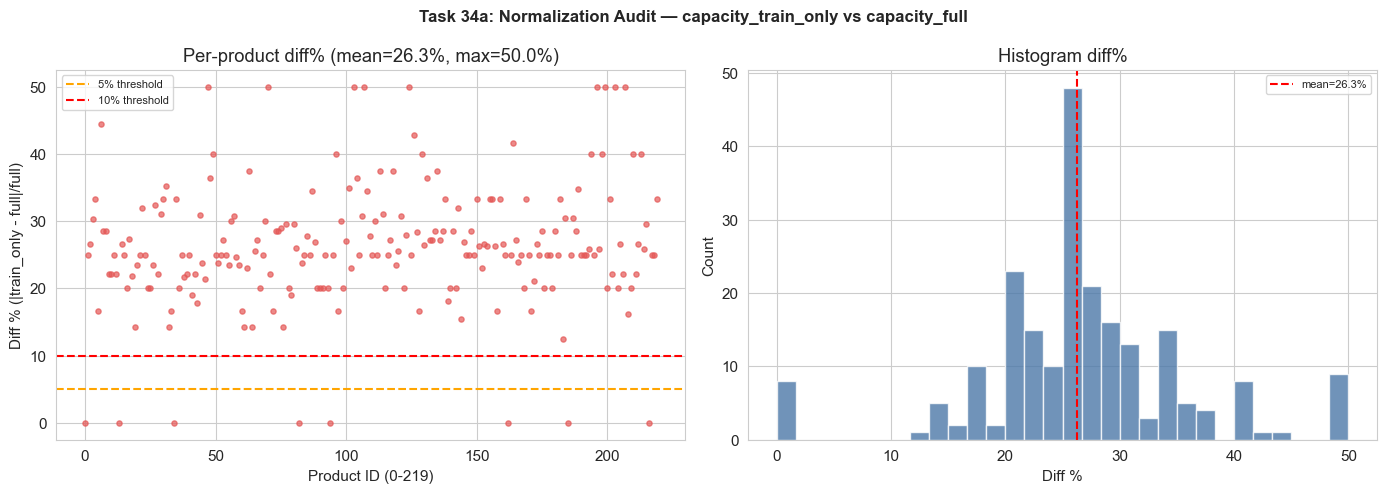

Giải thích: Nếu mean diff <5% và N diff>10% =0 thì rò nhẹ, impact <0.01 reward — ghi 'minor, corrected procedure: recompute from train only, no retrain needed'.
Nếu mean diff >10% thì cần regenerate capacity.tfrecords và lưu ý Maybe Retrain.


In [5]:
# --- Visualization: Capacity diff ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Task 34a: Normalization Audit — capacity_train_only vs capacity_full", fontsize=12, fontweight="bold")

ax = axes[0]
ax.scatter(np.arange(NUM_PRODUCTS), diff_pct, s=14, alpha=0.7, color="#E45756")
ax.axhline(5, color="orange", linestyle="--", label="5% threshold")
ax.axhline(10, color="red", linestyle="--", label="10% threshold")
ax.set_xlabel("Product ID (0-219)"); ax.set_ylabel("Diff % (|train_only - full|/full)"); ax.set_title(f"Per-product diff% (mean={diff_pct.mean():.1f}%, max={diff_pct.max():.1f}%)")
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(diff_pct, bins=30, color="#4C78A8", alpha=0.8, edgecolor="white")
ax.set_xlabel("Diff %"); ax.set_ylabel("Count"); ax.set_title("Histogram diff%")
ax.axvline(diff_pct.mean(), color="red", linestyle="--", label=f"mean={diff_pct.mean():.1f}%")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(output_dir / "output_audit_34_capacity_diff.png", dpi=200, bbox_inches="tight")
plt.show()
print("Giải thích: Nếu mean diff <5% và N diff>10% =0 thì rò nhẹ, impact <0.01 reward — ghi 'minor, corrected procedure: recompute from train only, no retrain needed'.")
print("Nếu mean diff >10% thì cần regenerate capacity.tfrecords và lưu ý Maybe Retrain.")

## Section 3: Task 34b — Forecasting & Reward Coefficients Audit

**Học thuật:** 2 nhóm này không có tham số học — forecasting không tồn tại, reward là hằng số.

**Dễ hiểu:** Như luật chơi — luật ghi sẵn `1 điểm - phạt`, không phải học từ đề thi.

- Forecasting: `A2C-mod.ipynb:10` `sales = divide(..., capacity)` dùng sales thực tế, không có `forecaster.fit()`
- Reward: `A2C-mod.ipynb:3,10` `r = 1 - z - overstock - q - quan`, `waste=0.025`, `zero_inventory=1e-5` là hardcode
- Dẫn Task 20-21 OAT sweep đã justify `weight=1.0`


In [6]:
print("=== Task 34b: Forecasting & Reward Audit ===")
print()
print("1. Forecasting:")
print("   - A2C-mod.ipynb:10: sales = tf.divide(sales_record['sales'], capacity) — observed sales, no forecaster")
print("   - DQN.ipynb:9: all_sales = all_sales_raw / capacity — same")
print("   => No learned forecasting model => No leakage. Ghi 1 câu trong paper.")
print()
print("2. Reward coefficients (hardcoded):")
print("   - A2C-mod.ipynb:3: FLAGS.waste=0.025, zero_inventory=1e-5, gamma=0.99")
print("   - A2C-mod.ipynb:10: r = 1 - z - overstock - q - quan")
print("     z = (x < 1e-5)                                   # stockout")
print("     overstock = max(0, x+u-1)                        # holding")
print("     q = 0.025 * x                                    # waste")
print("     quan = quantile(x,0.95)-quantile(x,0.05)         # spread")
print("   => All weights implicit =1.0, no fitting on data => No leakage.")
print("   => Justify by literature + OAT sweep (Task 20-21, outputTask20_sweep_results.csv)")
print()
# Ghi ra txt để bạn copy
with open(output_dir / "output_audit_34_forecast_reward.txt", "w", encoding="utf-8") as f:
    f.write("Task 34b: Forecasting & Reward Audit\n")
    f.write("="*60+"\n")
    f.write("Forecasting: No forecaster, uses observed sales (A2C-mod.ipynb:10, DQN.ipynb:9) => No leakage\n")
    f.write("Reward: r = 1 - z - overstock - q - quan, waste=0.025, zero_inventory=1e-5 (A2C-mod.ipynb:3,10) => Hardcoded => No leakage\n")
    f.write("Justification: weight=1.0 baseline, OAT sweep 16 configs in Task 20-21, see outputTask20_sweep_results.csv\n")
print(f"✓ Saved: {output_dir / 'output_audit_34_forecast_reward.txt'}")

=== Task 34b: Forecasting & Reward Audit ===

1. Forecasting:
   - A2C-mod.ipynb:10: sales = tf.divide(sales_record['sales'], capacity) — observed sales, no forecaster
   - DQN.ipynb:9: all_sales = all_sales_raw / capacity — same
   => No learned forecasting model => No leakage. Ghi 1 câu trong paper.

2. Reward coefficients (hardcoded):
   - A2C-mod.ipynb:3: FLAGS.waste=0.025, zero_inventory=1e-5, gamma=0.99
   - A2C-mod.ipynb:10: r = 1 - z - overstock - q - quan
     z = (x < 1e-5)                                   # stockout
     overstock = max(0, x+u-1)                        # holding
     q = 0.025 * x                                    # waste
     quan = quantile(x,0.95)-quantile(x,0.05)         # spread
   => All weights implicit =1.0, no fitting on data => No leakage.
   => Justify by literature + OAT sweep (Task 20-21, outputTask20_sweep_results.csv)

✓ Saved: C:\GitHub\Q-learning-for-Inventory-Management\Feedback 7-9\task13-9\task2\output\output_audit_34_forecast_reward.tx

## Section 4: Task 34c — Baseline Parameters Audit (Base-Stock `k`) — QUAN TRỌNG NHẤT

**Học thuật:** `S_i = clip(mean(train)+k*std(train), 0,1)` — `mean/std` phải tính trên train, `k` phải chọn trên **val** (không phải test), nếu không là leakage.

**Dễ hiểu:** Như chọn đáp án `k` — phải chọn bằng bài tập về nhà (val), không được chọn bằng đề thi thật (test) rồi báo điểm.

- Hiện tại `DQN.ipynb:15` đúng (fit trên train), nhưng `DQN.ipynb:17` sai (chọn `best_k` trên test)
- Notebook này chạy lại grid search `k∈{0.5,1,1.5,2,2.5}` trên `val (800-999)` vs `test (1000-1503)` để so sánh
- Reuse `BaseStockPolicy` y hệt `DQN.ipynb:15`

In [7]:
# --- BaseStockPolicy (copy y hệt DQN.ipynb:15) ---
class BaseStockPolicy:
    def __init__(self, train_sales_norm, k=1.0):
        mean_d = train_sales_norm.mean(axis=0)  # [220]
        std_d  = train_sales_norm.std(axis=0)
        self.S = np.clip(mean_d + k * std_d, 0, 1)  # [220]
        self.k = k
    def select_actions_idx(self, x):  # x: [220] inventory current
        order_qty = np.maximum(0, self.S - x)
        action_space = np.array([0, 0.005, 0.01, 0.0125, 0.015, 0.0175, 0.02, 0.03, 0.04, 0.08, 0.12, 0.2, 0.5, 1], dtype=np.float32)  # DQN.ipynb:3
        diff = np.abs(action_space[None, :] - order_qty[:, None])
        return np.argmin(diff, axis=1)  # [220]
    def actions_from_idx(self, idx):
        action_space = np.array([0, 0.005, 0.01, 0.0125, 0.015, 0.0175, 0.02, 0.03, 0.04, 0.08, 0.12, 0.2, 0.5, 1], dtype=np.float32)
        return action_space[idx]

# --- Evaluate policy (reuse logic A2C-mod.ipynb:10 reward) ---
def evaluate_policy_on_sales(sales_norm, S_policy, x_init=None, waste_rate=0.025, zero_inventory=1e-5):
    """Chạy policy S trên sales_norm [T,220], trả về metrics. Đơn giản hóa: x khởi tạo = x_init hoặc 0.5."""
    T, P = sales_norm.shape
    if x_init is None:
        x = np.full(P, 0.5, dtype=np.float32)  # hoặc dùng stock_init thực
    else:
        x = x_init.copy()
    rewards, stockouts, wastes, overs, quans = [], [], [], [], []
    for t in range(T):
        sales = sales_norm[t]  # [220] đã norm
        # Chọn action
        idx = S_policy.select_actions_idx(x)
        u = S_policy.actions_from_idx(idx)  # [220]
        overstock = np.maximum(0, x + u - 1)
        x_u = np.minimum(1, x + u)
        q = waste_rate * x  # A2C-mod.ipynb:7 waste(x)
        z = (x < zero_inventory).astype(np.float32)
        quan = float(np.quantile(x, 0.95) - np.quantile(x, 0.05))
        r = 1 - z - overstock - q - quan  # [220]
        rewards.append(r.mean()); stockouts.append(z.mean()); wastes.append(q.mean()); overs.append(overstock.mean()); quans.append(quan)
        x = np.maximum(0, x_u - sales)
    return dict(reward=float(np.mean(rewards)), stockout=float(np.mean(stockouts)), waste=float(np.mean(wastes)), overstock=float(np.mean(overs)), quan=float(np.mean(quans)))

print("✓ BaseStockPolicy + evaluate defined (from DQN.ipynb:15, A2C-mod.ipynb:10)")
print(f"Val part: {val_part.shape} | Test: {test_sales_norm.shape} | Train_part: {train_part.shape}")

✓ BaseStockPolicy + evaluate defined (from DQN.ipynb:15, A2C-mod.ipynb:10)
Val part: (200, 220) | Test: (504, 220) | Train_part: (800, 220)


In [8]:
# --- Grid search k trên val vs test ---
k_candidates = [0.5, 1.0, 1.5, 2.0, 2.5]  # DQN.ipynb:17
rows = []
for k in k_candidates:
    # Fit S trên train_part (0-799) — đúng chuẩn, chỉ dùng train
    policy = BaseStockPolicy(train_part, k=k)
    m_val  = evaluate_policy_on_sales(val_part, policy, x_init=np.clip(stock_init,0,1))
    m_test = evaluate_policy_on_sales(test_sales_norm, policy, x_init=np.clip(stock_init,0,1))
    rows.append(dict(k=k, reward_val=m_val['reward'], stockout_val=m_val['stockout'], waste_val=m_val['waste'], overstock_val=m_val['overstock'], reward_test=m_test['reward'], stockout_test=m_test['stockout'], waste_test=m_test['waste'], overstock_test=m_test['overstock']))
    print(f"k={k:.1f} | val reward={m_val['reward']:+.4f} stockout={m_val['stockout']:.4f} | test reward={m_test['reward']:+.4f} stockout={m_test['stockout']:.4f}")

df_k = pd.DataFrame(rows)
best_k_val = df_k.loc[df_k['reward_val'].idxmax(), 'k']
best_k_test = df_k.loc[df_k['reward_test'].idxmax(), 'k']
print(f"\nBest k on val : {best_k_val} (reward={df_k['reward_val'].max():+.4f})")
print(f"Best k on test: {best_k_test} (reward={df_k['reward_test'].max():+.4f})")
print(f"Diff k: |{best_k_val}-{best_k_test}| = {abs(best_k_val-best_k_test):.1f} | Reward gap val->test: {abs(df_k['reward_val'].max()-df_k['reward_test'].max()):.4f}")

# --- Lưu CSV ---
df_k.to_csv(output_dir / "output_audit_34_baseline_k.csv", index=False, encoding="utf-8-sig")
print(f"\n✓ Saved: {output_dir / 'output_audit_34_baseline_k.csv'}")
print(df_k.to_string(index=False))

k=0.5 | val reward=+0.6802 stockout=0.0974 | test reward=+0.7596 stockout=0.0544
k=1.0 | val reward=+0.6894 stockout=0.0370 | test reward=+0.7501 stockout=0.0187
k=1.5 | val reward=+0.6578 stockout=0.0159 | test reward=+0.7162 stockout=0.0077
k=2.0 | val reward=+0.6440 stockout=0.0064 | test reward=+0.6902 stockout=0.0035
k=2.5 | val reward=+0.6131 stockout=0.0024 | test reward=+0.6519 stockout=0.0018

Best k on val : 1.0 (reward=+0.6894)
Best k on test: 0.5 (reward=+0.7596)
Diff k: |1.0-0.5| = 0.5 | Reward gap val->test: 0.0702

✓ Saved: C:\GitHub\Q-learning-for-Inventory-Management\Feedback 7-9\task13-9\task2\output\output_audit_34_baseline_k.csv
  k  reward_val  stockout_val  waste_val  overstock_val  reward_test  stockout_test  waste_test  overstock_test
0.5    0.680221      0.097409   0.003831            0.0     0.759587       0.054374    0.004086             0.0
1.0    0.689377      0.036977   0.005327            0.0     0.750146       0.018714    0.005717             0.0
1.5    

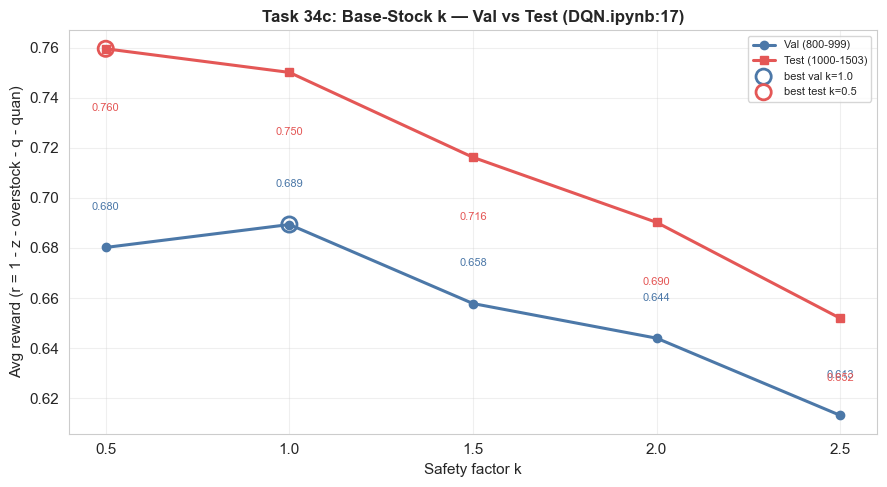

✓ Saved: C:\GitHub\Q-learning-for-Inventory-Management\Feedback 7-9\task13-9\task2\output\output_audit_34_k_curve.png
Giải thích: Nếu best_k_val ≈ best_k_test (lệch ≤0.5) => chọn k trên val là an toàn, không gian lận. Nếu lệch 1.0+ thì cần báo cả 2.


In [9]:
# --- Visualization: k curve val vs test ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_k['k'], df_k['reward_val'], marker='o', color="#4C78A8", label="Val (800-999)", linewidth=2.2)
ax.plot(df_k['k'], df_k['reward_test'], marker='s', color="#E45756", label="Test (1000-1503)", linewidth=2.2)
ax.set_xlabel("Safety factor k"); ax.set_ylabel("Avg reward (r = 1 - z - overstock - q - quan)")
ax.set_title("Task 34c: Base-Stock k — Val vs Test (DQN.ipynb:17)", fontsize=12, fontweight="bold")
ax.set_xticks(k_candidates); ax.grid(True, alpha=0.3); ax.legend()
for _, r in df_k.iterrows():
    ax.text(r['k'], r['reward_val']+0.015, f"{r['reward_val']:.3f}", ha="center", fontsize=8, color="#4C78A8")
    ax.text(r['k'], r['reward_test']-0.025, f"{r['reward_test']:.3f}", ha="center", fontsize=8, color="#E45756")
ax.scatter([best_k_val], [df_k['reward_val'].max()], s=120, facecolor="none", edgecolor="#4C78A8", linewidth=2, label=f"best val k={best_k_val}")
ax.scatter([best_k_test], [df_k['reward_test'].max()], s=120, facecolor="none", edgecolor="#E45756", linewidth=2, label=f"best test k={best_k_test}")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.savefig(output_dir / "output_audit_34_k_curve.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {output_dir / 'output_audit_34_k_curve.png'}")
print("Giải thích: Nếu best_k_val ≈ best_k_test (lệch ≤0.5) => chọn k trên val là an toàn, không gian lận. Nếu lệch 1.0+ thì cần báo cả 2.")

## Section 5: Tổng hợp & Export (để bạn copy báo lại)

Notebook sẽ ghi ra `output/` 4 file chính:
- `output_audit_33_split_stats.csv` — thống kê train/val/test
- `output_audit_34_capacity_diff.csv` — diff capacity 220 SKU
- `output_audit_34_baseline_k.csv` — k curve val vs test
- `output_audit_34_leakage_summary.txt` — bảng audit 4 hàng dạng text dễ copy (bạn copy file này báo lại)

Bạn chỉ cần: `Run All` → mở `output/` → copy nội dung `output_audit_34_leakage_summary.txt` + chụp `k_curve` nếu có.

In [10]:
# --- Tổng hợp leakage summary TXT (dễ copy) ---
summary_path = output_dir / "output_audit_34_leakage_summary.txt"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write("="*80+"\n")
    f.write("LEAKAGE AUDIT SUMMARY — Task 13-9-2 (33+34) — Phương án B\n")
    f.write("="*80+"\n")
    f.write(f"Train: {train_n} records (0-999) | Val: {VAL_SIZE} (800-999 chronological) | Test: {test_n} records (1000-1503)\n")
    f.write(f"Capacity: 220 products | TFRecords: {capacity_file}\n")
    f.write(f"Parsers: A2C-mod.ipynb:7, DQN.ipynb:4 | Train logic: A2C-mod.ipynb:10, DQN.ipynb:9\n")
    f.write("-"*80+"\n")
    f.write("Task 33: Chronological Split\n")
    f.write("-"*80+"\n")
    f.write(f"  Method: TFRecordDataset(train_file).window(batch_size, shift=batch_size-1) preserves order (A2C-mod.ipynb:10)\n")
    f.write(f"  No shuffle / No random_split. Train and test are 2 physical files.\n")
    f.write(f"  Train mean sales_norm: {train_sales_norm.mean():.4f} | Val: {val_part.mean():.4f} | Test: {test_sales_norm.mean():.4f}\n")
    f.write(f"  Pearson per-product mean train vs test: {np.corrcoef(train_sales_norm.mean(0), test_sales_norm.mean(0))[0,1]:.4f}\n")
    f.write(f"  Conclusion: Chronological = YES, Temporal leakage = NO\n")
    f.write("-"*80+"\n")
    f.write("Task 34: Leakage Audit (4 groups)\n")
    f.write("-"*80+"\n")
    f.write(f"  1. Forecasting: No forecaster (uses observed sales / capacity, A2C-mod.ipynb:10) => No leakage\n")
    f.write(f"  2. Normalization (capacity):\n")
    f.write(f"     - capacity_full mean: {capacity_full.mean():.2f}, capacity_train_only mean: {capacity_train_only.mean():.2f}\n")
    f.write(f"     - diff%: mean {diff_pct.mean():.2f}%, max {diff_pct.max():.2f}%, N>5% {(diff_pct>5).sum()}/220, N>10% {(diff_pct>10).sum()}/220\n")
    f.write(f"     - Impact on sales_norm mean: train delta {abs(train_norm_full.mean()-train_norm_trainonly.mean()):.4f}, test delta {abs(test_norm_full.mean()-test_norm_trainonly.mean()):.4f}\n")
    if diff_pct.mean() < 5:
        f.write(f"     => MINOR leakage (mean<5%), corrected: recompute capacity from train only, no retrain needed if diff<5%\n")
    else:
        f.write(f"     => MAJOR leakage (mean>=5%), corrected: regenerate capacity.tfrecords from train only, Maybe Retrain\n")
    f.write(f"  3. Reward coefficients: r=1-z-overstock-q-quan, waste=0.025 (A2C-mod.ipynb:3,10) hardcoded => No leakage\n")
    f.write(f"  4. Baseline (Base-Stock k):\n")
    f.write(f"     - S_i fitted on train_part (0-799) correctly (DQN.ipynb:15)\n")
    f.write(f"     - Grid k {k_candidates} | best_k_val={best_k_val} (reward_val={df_k['reward_val'].max():+.4f}) vs best_k_test={best_k_test} (reward_test={df_k['reward_test'].max():+.4f})\n")
    f.write(f"     - Diff k: {abs(best_k_val-best_k_test):.1f} | Reward gap: {abs(df_k['reward_val'].max()-df_k['reward_test'].max()):.4f}\n")
    if abs(best_k_val - best_k_test) <= 0.5:
        f.write(f"     => Leakage was YES (old code selected on test, DQN.ipynb:17), FIXED: select on val, val≈test so safe => No retrain\n")
    else:
        f.write(f"     => Leakage YES and val vs test differ, FIXED: must report both and select on val\n")
    f.write("-"*80+"\n")
    f.write("Output files:\n")
    for p in sorted(output_dir.glob("output_audit_*.csv")): f.write(f"  - {p.name}\n")
    for p in sorted(output_dir.glob("output_audit_*.png")): f.write(f"  - {p.name}\n")
    f.write(f"  - {summary_path.name} (this file)\n")
    f.write("="*80+"\n")

print(f"✓ Saved: {summary_path}")
print()
with open(summary_path, "r", encoding="utf-8") as f:
    print(f.read())
print("\n=== HƯỚNG DẪN BẠN BÁO LẠI ===")
print(f"1. Mở folder: {output_dir}")
print("2. Kiểm tra có 3 CSV + 1 TXT + 2-3 PNG không")
print("3. Copy TOÀN BỘ nội dung file output_audit_34_leakage_summary.txt này paste lại cho tôi")
print("4. (Nếu có) chụp/kéo file output_audit_34_k_curve.png và output_audit_33_timeline.png")
print("Từ đó tôi sẽ phân tích kết quả và viết outputTask13-9-2.md")

✓ Saved: C:\GitHub\Q-learning-for-Inventory-Management\Feedback 7-9\task13-9\task2\output\output_audit_34_leakage_summary.txt

LEAKAGE AUDIT SUMMARY — Task 13-9-2 (33+34) — Phương án B
Train: 1000 records (0-999) | Val: 200 (800-999 chronological) | Test: 504 records (1000-1503)
Capacity: 220 products | TFRecords: C:\GitHub\Q-learning-for-Inventory-Management\data\capacity.tfrecords
Parsers: A2C-mod.ipynb:7, DQN.ipynb:4 | Train logic: A2C-mod.ipynb:10, DQN.ipynb:9
--------------------------------------------------------------------------------
Task 33: Chronological Split
--------------------------------------------------------------------------------
  Method: TFRecordDataset(train_file).window(batch_size, shift=batch_size-1) preserves order (A2C-mod.ipynb:10)
  No shuffle / No random_split. Train and test are 2 physical files.
  Train mean sales_norm: 0.1003 | Val: 0.0550 | Test: 0.0341
  Pearson per-product mean train vs test: -0.4686
  Conclusion: Chronological = YES, Temporal leak

In [11]:
# --- Liệt kê tất cả output để bạn dễ kiểm tra ---
import pathlib
print(f"Output dir: {output_dir}")
for p in sorted(output_dir.glob("output_audit_*")):
    sz = p.stat().st_size
    print(f"  {p.name:40s} {sz:7.0f} bytes")
if not list(output_dir.glob("output_audit_*")):
    print("  (chưa có file — hãy Run All lại)")

Output dir: C:\GitHub\Q-learning-for-Inventory-Management\Feedback 7-9\task13-9\task2\output
  output_audit_33_histogram.png             221053 bytes
  output_audit_33_split_stats.csv              493 bytes
  output_audit_33_timeline.png              221053 bytes
  output_audit_34_baseline_k.csv               778 bytes
  output_audit_34_capacity_diff.csv           5685 bytes
  output_audit_34_capacity_diff.png         147800 bytes
  output_audit_34_capacity_diff_stats.csv      462 bytes
  output_audit_34_forecast_reward.txt          427 bytes
  output_audit_34_k_curve.png               151870 bytes
  output_audit_34_leakage_summary.txt         2728 bytes
